---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 4**: Embeddings & Semantic Search

### 📅 **Due Date**: Day of Lecture 5, 11:59 PM


**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

In this homework, you'll build on Homework 3 (BM25 search) by adding **embedding-based semantic search**.

You will:
1. **Generate embeddings** using both local (Hugging Face) and API (OpenAI) models
2. **Implement cosine similarity** from scratch
3. **Implement semantic search** from scratch
4. **Compare BM25 vs semantic search** using Recall
5. **Compare different embedding models** and analyze their differences

**Total Points: 95**

---

## Instructions

- Complete all tasks by filling in code where you see `# YOUR CODE HERE`
- You may use ChatGPT, Claude, documentation, Stack Overflow, etc.
- When using external resources, briefly cite them in a comment
- Run all cells before submitting to ensure they work

**Submission:**
1. Create a branch called `homework-4`
2. Commit and push your work
3. Create a PR and merge to main
4. Submit the `.ipynb` file on Blackboard

---

## Task 1: Environment Setup (10 points)

### 1a. Imports (5 pts)

Import the required libraries and load the WANDS data.

In [1]:
import os, sys

print("CWD:", os.getcwd())
print("Root files:", os.listdir("."))
print("scripts exists:", os.path.isdir("scripts"))
if os.path.isdir("scripts"):
    print("scripts contents:", os.listdir("scripts"))


CWD: /Users/pavitravenkatesh/Desktop/ai-engineering-fordham-backup/homework
Root files: ['homework-1.ipynb', 'homework-3.ipynb', 'homework-2.ipynb', 'homework-4.ipynb', '4.embeddings-semantic-search.ipynb']
scripts exists: False


In [2]:
# ruff: noqa: E402

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

# Import ONLY data loading from helpers
import sys
sys.path.append('../scripts')
from helpers import load_wands_products, load_wands_queries, load_wands_labels

# Embedding libraries - we use these directly
from sentence_transformers import SentenceTransformer
import litellm

# Load environment variables for API keys
from dotenv import load_dotenv
load_dotenv()

pd.set_option('display.max_colwidth', 80)
print("All imports successful!")

All imports successful!


In [3]:
# Load the WANDS dataset
products = load_wands_products()
queries = load_wands_queries()
labels = load_wands_labels()

print(f"Products: {len(products):,}")
print(f"Queries: {len(queries):,}")
print(f"Labels: {len(labels):,}")

Products: 42,994
Queries: 480
Labels: 233,448


### 1b. Copy BM25 functions from HW3 (5 pts)

Copy your BM25 implementation from Homework 3. We'll use it to compare against semantic search.

In [4]:
# Copy your BM25 functions from Homework 3
# Note: We'll use the ones from helpers.py instead

from helpers import snowball_tokenize, build_index, score_bm25, search_bm25

print("✅ BM25 functions imported from helpers.py")
print("Available functions: snowball_tokenize, build_index, score_bm25, search_bm25")


✅ BM25 functions imported from helpers.py
Available functions: snowball_tokenize, build_index, score_bm25, search_bm25


---

## Task 2: Understanding Embeddings (15 points)

### 2a. Load a local model and generate embeddings (5 pts)

Use `sentence-transformers` to load a local embedding model and generate embeddings for a list of words.

In [5]:
# Load the all-MiniLM-L6-v2 model using SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

# List of words to embed
words = ["wooden coffee table", "oak dining table", "red leather sofa", "blue area rug", "kitchen sink"]

# Generate embeddings
word_embeddings = model.encode(words)

# Print the results
print(f"Number of embeddings generated: {len(word_embeddings)}")
print(f"Dimension of each embedding: {word_embeddings.shape[1]}")

Number of embeddings generated: 5
Dimension of each embedding: 384


### 2b. Implement cosine similarity and create a similarity matrix (5 pts)

Implement cosine similarity from scratch:

$$\text{cosine\_similarity}(a, b) = \frac{a \cdot b}{\|a\| \times \|b\|}$$

In [6]:
def cosine_similarity(a, b):
    # YOUR CODE HERE
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)

# Create similarity matrix for the words above
num_words = len(words)
sim_matrix = np.zeros((num_words, num_words))

for i in range(num_words):
    for j in range(num_words):
        sim_matrix[i, j] = cosine_similarity(word_embeddings[i], word_embeddings[j])

# Display as DataFrame
sim_df = pd.DataFrame(sim_matrix, index=words, columns=words)
display(sim_df)


,wooden coffee table,oak dining table,red leather sofa,blue area rug,kitchen sink
wooden coffee table,1.000000,0.588631,0.370622,0.189486,0.295712
oak dining table,0.588631,1.000000,0.337910,0.249521,0.341410
red leather sofa,0.370622,0.337910,1.000000,0.380310,0.057740
blue area rug,0.189486,0.249521,0.380310,1.000000,0.125802
kitchen sink,0.295712,0.341410,0.057740,0.125802,1.000000


### 2c. Embed using OpenAI API (5 pts)

Use `litellm` to get embeddings from OpenAI's API and compare dimensions.

In [7]:
# Use litellm to get an embedding from OpenAI's text-embedding-3-small model
# Compare the dimension with the local model
response = litellm.embedding(model="text-embedding-3-small", input=["wooden coffee table"])
openai_emb = np.array(response.data[0]["embedding"])

print(f"OpenAI dimension: {len(openai_emb)}")
print(f"Local model dimension: {word_embeddings.shape[1]}")

OpenAI dimension: 1536
Local model dimension: 384


---

## Task 3: Batch Embedding Products (20 points)

### 3a. Embed a product sample (10 pts)

Create a combined text field and embed 5,000 products using the local model.

In [8]:
# Get a consistent sample
products_sample = products.sample(n=5000, random_state=42).reset_index(drop=True)

In [9]:
# Create a combined text field (product_name + product_class)
products_sample['embed_text'] = (
    products_sample['product_name'].fillna('') + ' ' + 
    products_sample['product_class'].fillna('')
)

# Embed all products using the local model (model.encode)
# This may take a minute or two depending on your machine
print("Embedding 5,000 products...")
product_embeddings = model.encode(products_sample['embed_text'].tolist(), show_progress_bar=True)

print(f"Embeddings generated. Shape: {product_embeddings.shape}")


Embedding 5,000 products...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embeddings generated. Shape: (5000, 384)


### 3b. Save and load embeddings (5 pts)

Save embeddings to a `.npy` file so you don't have to recompute them.

In [10]:
import os

# Create temp directory if it doesn't exist
os.makedirs('../temp', exist_ok=True)

# Save embeddings and the product sample
np.save('../temp/hw4_embeddings.npy', product_embeddings)
products_sample.to_csv('../temp/hw4_products.csv', index=False)

# Load them back to verify
loaded_embeddings = np.load('../temp/hw4_embeddings.npy')
loaded_products = pd.read_csv('../temp/hw4_products.csv')

# Verify the shapes match
print(f"Original shape: {product_embeddings.shape}")
print(f"Loaded shape:   {loaded_embeddings.shape}")

Original shape: (5000, 384)
Loaded shape:   (5000, 384)


### 3c. Cost estimation (5 pts)

Estimate the cost to embed all 43K products using OpenAI's API.

**Pricing**: text-embedding-3-small costs ~$0.02 per 1 million tokens.

In [11]:
import tiktoken

# Initialize the encoder for the OpenAI model
enc = tiktoken.encoding_for_model("text-embedding-3-small")

# 1. Count tokens in your 5,000 product sample
sample_text = " ".join(products_sample['embed_text'].tolist())
total_sample_tokens = len(enc.encode(sample_text))

# 2. Extrapolate to the full 43,000 products
avg_tokens_per_product = total_sample_tokens / 5000
estimated_total_tokens = avg_tokens_per_product * 43000

# 3. Calculate cost ($0.02 per 1M tokens)
estimated_cost = (estimated_total_tokens / 1_000_000) * 0.02

print(f"Average tokens per product: {avg_tokens_per_product:.2f}")
print(f"Estimated total tokens for 43K products: {estimated_total_tokens:,.0f}")
print(f"Estimated cost for OpenAI embeddings: ${estimated_cost:.4f}")

Average tokens per product: 12.96
Estimated total tokens for 43K products: 557,194
Estimated cost for OpenAI embeddings: $0.0111


---

## Task 4: Semantic Search (25 points)

### 4a. Implement semantic search (15 pts)

Implement a semantic search function from scratch.

In [12]:
# Implement batch cosine similarity for efficiency
def batch_cosine_similarity(query_emb, document_embeddings):
    """
    Calculates cosine similarity between a single query vector and a matrix of document vectors.
    """
    # Ensure query is a 2D array for matrix multiplication
    if query_emb.ndim == 1:
        query_emb = query_emb.reshape(1, -1)
        
    # Dot product: (1 x dim) * (dim x num_docs) -> (1 x num_docs)
    dot_product = np.dot(query_emb, document_embeddings.T)
    
    # Calculate norms for normalization
    query_norm = np.linalg.norm(query_emb, axis=1, keepdims=True)
    doc_norms = np.linalg.norm(document_embeddings, axis=1, keepdims=True)
    
    # Cosine similarity formula: dot(a, b) / (||a|| * ||b||)
    similarity = dot_product / (query_norm * doc_norms.T)
    
    return similarity.flatten()

In [13]:
# Implement semantic search
def semantic_search(query, model, product_embeddings, products_df, k=10):
    # 1. Generate embedding for the search query
    query_emb = model.encode(query, convert_to_numpy=True)
    
    # 2. Calculate similarity scores against all products
    similarities = batch_cosine_similarity(query_emb, product_embeddings)
    
    # 3. Get indices of the top-k highest scores
    top_k_idx = np.argsort(-similarities)[:k]
    
    # 4. Return the corresponding products and their scores
    results = products_df.iloc[top_k_idx].copy()
    results['similarity'] = similarities[top_k_idx]
    results['rank'] = range(1, k + 1)
    
    return results


In [14]:
# Test semantic search
test_results = semantic_search("comfortable modular sofa", model, product_embeddings, products_sample, k=5)
display(test_results[['rank', 'product_name', 'product_class', 'similarity']])

,rank,product_name,product_class,similarity
4683,1,106.5 '' wide symmetrical modular sofa & chaise,Sectionals,0.764928
2120,2,kendall sectional sofa with ottoman,Sectionals,0.759946
3226,3,aireka 103.5 '' wide reversible modular sofa & chaise with ottoman,Sectionals,0.752010
794,4,akiko 104 '' wide velvet reversible modular sofa & chaise with ottoman,Sectionals,0.751293
2695,5,aelber 170 '' wide reversible modular sofa & chaise with ottoman,Sectionals,0.743226


### 4b. Evaluate and compare BM25 vs semantic search (10 pts)

Implement Recall@k and compare the two search methods.

In [15]:
# Implement Recall@k
def calculate_recall_at_k(results_df, query_id, labels_df, k=10):
    # Get the list of product IDs marked as relevant for this query in the ground truth
    relevant_ids = set(labels_df[labels_df['query_id'] == query_id]['product_id'])
    
    if not relevant_ids:
        return 0.0
    
    # Get the IDs of the top k products returned by our search
    top_k_ids = set(results_df['product_id'].head(k))
    
    # Calculate intersection (hits)
    hits = len(relevant_ids.intersection(top_k_ids))
    
    return hits / len(relevant_ids)

In [16]:
# Build BM25 index for comparison
from helpers import build_index, search_bm25
sample_index, sample_lengths = build_index(products_sample['product_name'].tolist())
# Filter queries to those with products in our sample
sample_product_ids = set(products_sample['product_id'])
relevant_labels = labels[labels['product_id'].isin(sample_product_ids)]
sample_query_ids = set(relevant_labels['query_id'])
test_queries = queries[queries['query_id'].isin(sample_query_ids)]

print(f"Evaluating on {len(test_queries)} applicable queries...")

Evaluating on 473 applicable queries...


In [17]:
# Evaluate both BM25 and semantic search on all queries
# Calculate Recall@10 for each method
bm25_recalls = []
semantic_recalls = []

for _, row in test_queries.iterrows():
    qid, qtext = row['query_id'], row['query']
    
    # BM25 Search
    res_bm25 = search_bm25(qtext, sample_index, products_sample, sample_lengths, k=10)
    bm25_recalls.append(calculate_recall_at_k(res_bm25, qid, relevant_labels, k=10))
    
    # Semantic Search
    res_sem = semantic_search(qtext, model, product_embeddings, products_sample, k=10)
    semantic_recalls.append(calculate_recall_at_k(res_sem, qid, relevant_labels, k=10))

print(f"Mean Recall@10 (BM25): {np.mean(bm25_recalls):.4f}")
print(f"Mean Recall@10 (Semantic): {np.mean(semantic_recalls):.4f}")

Mean Recall@10 (BM25): 0.3155
Mean Recall@10 (Semantic): 0.2680


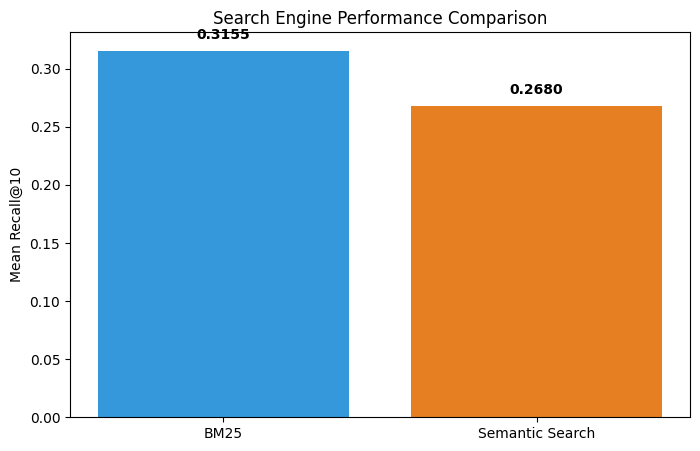

In [18]:
# Visualize comparison
import matplotlib.pyplot as plt

methods = ['BM25', 'Semantic Search']
scores = [np.mean(bm25_recalls), np.mean(semantic_recalls)]

plt.figure(figsize=(8, 5))
plt.bar(methods, scores, color=['#3498db', '#e67e22'])
plt.ylabel('Mean Recall@10')
plt.title('Search Engine Performance Comparison')
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

---

## Task 5: Compare Embedding Models (20 points)

### 5a. Embed products with two different models (10 pts)

Compare embeddings from:
- `BAAI/bge-base-en-v1.5`
- `sentence-transformers/all-mpnet-base-v2`

In [19]:
# Load the two embedding models
model_bge = SentenceTransformer('BAAI/bge-small-en-v1.5')
model_mpnet = SentenceTransformer('all-mpnet-base-v2')

In [20]:
# Embed products with both models
print("Generating BGE embeddings...")
embeddings_bge = model_bge.encode(products_sample['embed_text'].tolist(), show_progress_bar=True)

print("Generating MPNet embeddings...")
embeddings_mpnet = model_mpnet.encode(products_sample['embed_text'].tolist(), show_progress_bar=True)

Generating BGE embeddings...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Generating MPNet embeddings...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

### 5b. Compare search results between models (10 pts)

Evaluate both models on the same queries and analyze differences.

In [21]:
import numpy as np

def batch_cosine_similarity(query_emb, document_embeddings):
    # query_emb: shape (dim,) or (1, dim)
    # document_embeddings: shape (n_docs, dim)
    if query_emb.ndim == 1:
        query_emb = query_emb.reshape(1, -1)

    dot_product = np.dot(query_emb, document_embeddings.T)  # (1, n_docs)
    query_norm = np.linalg.norm(query_emb, axis=1, keepdims=True)  # (1,1)
    doc_norms = np.linalg.norm(document_embeddings, axis=1, keepdims=True)  # (n_docs,1)

    similarity = dot_product / (query_norm * doc_norms.T)
    return similarity.flatten()

def semantic_search(query, model, product_embeddings, products_df, k=10):
    # model.encode(query, convert_to_numpy=True) returns (dim,)
    query_emb = model.encode(query, convert_to_numpy=True)
    similarities = batch_cosine_similarity(query_emb, product_embeddings)

    top_k_idx = np.argsort(-similarities)[:k]
    results = products_df.iloc[top_k_idx].copy()
    results["similarity"] = similarities[top_k_idx]
    results["rank"] = range(1, k + 1)
    return results



In [22]:
# Build product embeddings for both models on the same product list
product_texts = products_sample["product_name"].astype(str).tolist()

E_bge = model_bge.encode(product_texts, convert_to_numpy=True)
E_mpnet = model_mpnet.encode(product_texts, convert_to_numpy=True)

print("E_bge shape:", E_bge.shape)
print("E_mpnet shape:", E_mpnet.shape)
print("products_sample rows:", len(products_sample))


E_bge shape: (5000, 384)
E_mpnet shape: (5000, 768)
products_sample rows: 5000


In [23]:
# Use your evaluation set of queries from earlier (must have columns: query_id, query)
eval_queries_df = test_queries.copy()

bge_recalls = []
mpnet_recalls = []

for _, row in eval_queries_df.iterrows():
    qid = row["query_id"]
    qtext = row["query"]

    res_bge = semantic_search(qtext, model_bge, E_bge, products_sample, k=10)
    res_mpnet = semantic_search(qtext, model_mpnet, E_mpnet, products_sample, k=10)

    bge_recalls.append(calculate_recall_at_k(res_bge, qid, relevant_labels, k=10))
    mpnet_recalls.append(calculate_recall_at_k(res_mpnet, qid, relevant_labels, k=10))

results_5b = eval_queries_df[["query_id", "query"]].copy()
results_5b["bge_recall@10"] = bge_recalls
results_5b["mpnet_recall@10"] = mpnet_recalls
results_5b["delta_bge_minus_mpnet"] = results_5b["bge_recall@10"] - results_5b["mpnet_recall@10"]

print("Mean Recall@10 (BGE):", round(results_5b["bge_recall@10"].mean(), 4))
print("Mean Recall@10 (MPNet):", round(results_5b["mpnet_recall@10"].mean(), 4))
print("BGE wins:", round((results_5b["delta_bge_minus_mpnet"] > 0).mean(), 3))
print("MPNet wins:", round((results_5b["delta_bge_minus_mpnet"] < 0).mean(), 3))
print("Ties:", round((results_5b["delta_bge_minus_mpnet"] == 0).mean(), 3))

display(results_5b.sort_values("delta_bge_minus_mpnet", ascending=False).head(10))
display(results_5b.sort_values("delta_bge_minus_mpnet", ascending=True).head(10))



Mean Recall@10 (BGE): 0.2786
Mean Recall@10 (MPNet): 0.2597
BGE wins: 0.347
MPNet wins: 0.192
Ties: 0.461


,query_id,query,bge_recall@10,mpnet_recall@10,delta_bge_minus_mpnet
478,486,54 in bench cushion,0.818182,0.000000,0.818182
349,355,argenteuil,0.833333,0.333333,0.500000
6,6,acrylic clear chair,0.636364,0.181818,0.454545
313,318,sunjoy lantern,0.769231,0.384615,0.384615
448,455,deer coat hooks,0.625000,0.250000,0.375000
289,293,wood floor protector mat,0.636364,0.272727,0.363636
304,309,moen 5995 arbor one,0.333333,0.000000,0.333333
215,219,trinaic towel rod,0.333333,0.000000,0.333333
322,327,kohler purist brushed bronze,0.461538,0.153846,0.307692
153,153,bohemian,0.434783,0.130435,0.304348


,query_id,query,bge_recall@10,mpnet_recall@10,delta_bge_minus_mpnet
195,198,cake plates with tops,0.250000,0.750000,-0.500000
21,21,living curtains pearl,0.062500,0.500000,-0.437500
394,400,small ladies rocker swivel recliner,0.333333,0.666667,-0.333333
276,280,johan desk by laurel foundry,0.000000,0.285714,-0.285714
277,281,brunk ship wheel,0.363636,0.636364,-0.272727
460,467,town & country living curtains,0.105263,0.368421,-0.263158
393,399,12v dirt bike,0.500000,0.750000,-0.250000
163,164,modern outdoor furniture,0.050000,0.300000,-0.250000
308,313,malachi sled,0.222222,0.444444,-0.222222
324,329,wayfair tension rod,0.500000,0.700000,-0.200000


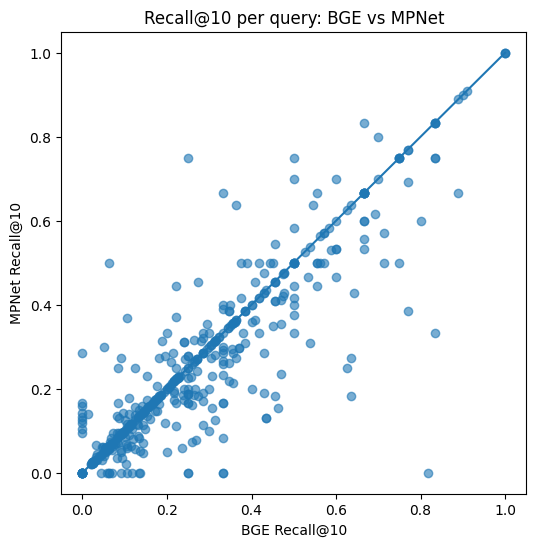

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(results_5b["bge_recall@10"], results_5b["mpnet_recall@10"], alpha=0.6)
plt.plot([0, 1], [0, 1])
plt.xlabel("BGE Recall@10")
plt.ylabel("MPNet Recall@10")
plt.title("Recall@10 per query: BGE vs MPNet")
plt.show()



---

## Task 6: Git Submission (5 points)

Submit your work using the Git workflow:

- [ ] Create a new branch called `homework-4`
- [ ] Commit your work with a meaningful message
- [ ] Push to GitHub
- [ ] Create a Pull Request
- [ ] Merge the PR to main
- [ ] Submit the `.ipynb` file on Blackboard

The TA will verify your submission by checking the merged PR on GitHub.